Import necessary packages

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score, f1_score, ConfusionMatrixDisplay, balanced_accuracy_score

In [9]:
df = pd.read_csv("../data/processed/calfire_with_gridmet_terrain.csv")
print("Shape:", df.shape)
display(df.head())
display(df[["Name", "AcresBurned", "severity_tier", "year", "month"]].head())

Shape: (2397, 179)


,gridmet_id,UniqueId,Name,StartedDateOnly,Latitude,Longitude,AcresBurned,gridmet_rows_available,n_days_7d,pr_mm_7d_mean,...,year,month,nwcg_size_class,severity_tier,size_tier,elevation,slope_degrees,aspect_degrees,northness,eastness
0,fire_00000,3135c367-1274-4cc4-9152-661f6fd7707e,Creek Fire,2016-10-10,38.409580,-122.431720,65.0,30,7,0.200000,...,2016,10,C,Small,Small,223.804140,2.0,246.0,-0.406737,-0.913545
1,fire_00001,7106ba43-100b-41f9-acbf-9fb9e9ab9ef7,Taglio Fire,2016-04-24,37.217100,-121.080360,30.0,30,7,0.185714,...,2016,4,C,Small,Small,62.611248,1.0,80.0,0.173648,0.984808
2,fire_00002,ffec404e-dea9-4175-8c50-8f2b0ca3efdd,Tulloch Fire,2016-05-30,37.927613,-120.528836,85.0,30,7,0.000000,...,2016,5,C,Small,Small,254.468410,5.0,246.0,-0.406737,-0.913545
3,fire_00003,55fa95e6-f09e-42c4-889b-a4b5b63dccf2,Metz Fire,2016-05-22,36.381230,-121.200590,3876.0,30,7,0.000000,...,2016,5,F,Large,Large,257.852000,11.0,134.0,-0.694658,0.719340
4,fire_00004,ace1f464-7a70-4dcc-b8c5-d64fb1021d0e,Wheatland Fire,2016-05-23,34.276000,-118.354000,156.0,30,7,0.000000,...,2016,5,D,Medium,Medium,395.886870,10.0,217.0,-0.798636,-0.601815


,Name,AcresBurned,severity_tier,year,month
0,Creek Fire,65.0,Small,2016,10
1,Taglio Fire,30.0,Small,2016,4
2,Tulloch Fire,85.0,Small,2016,5
3,Metz Fire,3876.0,Large,2016,5
4,Wheatland Fire,156.0,Medium,2016,5


In [10]:
required_cols = ["severity_tier", "AcresBurned", "year", "month", "Latitude", "Longitude"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["severity_tier"] = df["severity_tier"].astype(str)
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")

tier_order = ["Small", "Medium", "Large", "Extreme"]

df = df[df["severity_tier"].isin(tier_order)].copy()
df["severity_tier"] = pd.Categorical(df["severity_tier"], categories=tier_order, ordered=True)

print("Modeling table shape:", df.shape)
print("\nSeverity tier distribution:")
display(df["severity_tier"].value_counts().reindex(tier_order).to_frame("count"))

print("\nYear distribution:")
display(df["year"].value_counts().sort_index().to_frame("count"))


Modeling table shape: (2397, 179)

Severity tier distribution:


,count
severity_tier,
Small,1311
Medium,720
Large,200
Extreme,166



Year distribution:


,count
year,
2016,149
2017,411
2018,300
2019,257
2020,241
2021,179
2022,131
2023,121
2024,608


Time-based train/test split

In [11]:
train = df[df["year"].between(2016, 2021)].copy()
test = df[df["year"].between(2022, 2024)].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain target distribution:")
display(train["severity_tier"].value_counts().reindex(tier_order).to_frame("count"))

print("\nTest target distribution:")
display(test["severity_tier"].value_counts().reindex(tier_order).to_frame("count"))

print("\nTrain target proportions:")
display((train["severity_tier"].value_counts(normalize=True).reindex(tier_order) * 100).round(2).to_frame("percent"))

print("\nTest target proportions:")
display((test["severity_tier"].value_counts(normalize=True).reindex(tier_order) * 100).round(2).to_frame("percent"))


Train shape: (1537, 179)
Test shape: (860, 179)

Train target distribution:


,count
severity_tier,
Small,750
Medium,510
Large,153
Extreme,124



Test target distribution:


,count
severity_tier,
Small,561
Medium,210
Large,47
Extreme,42



Train target proportions:


,percent
severity_tier,
Small,48.80
Medium,33.18
Large,9.95
Extreme,8.07



Test target proportions:


,percent
severity_tier,
Small,65.23
Medium,24.42
Large,5.47
Extreme,4.88


In [12]:
curated_features = [
    # Location / season
    "Latitude",
    "Longitude",
    "month",

    # Weather / fire danger
    "tmmx_F_7d_mean",
    "tmmn_F_7d_mean",
    "vpd_kPa_7d_mean",
    "vs_m_s_7d_mean",
    "rmin_pct_7d_mean",
    "pr_mm_30d_sum",
    "erc_7d_mean",
    "bi_7d_mean",
    "fm100_pct_7d_mean",
    "fm1000_pct_30d_mean",

    # Terrain
    "elevation",
    "slope_degrees",
    "northness",
    "eastness",
]

curated_features = [c for c in curated_features if c in df.columns]

leakage_or_id_cols = {
    # Targets / target-derived
    "AcresBurned",
    "log_acres",
    "nwcg_size_class",
    "severity_tier",
    "size_tier",

    # Time split / labels / identifiers
    "gridmet_id",
    "UniqueId",
    "Name",
    "Url",
    "Location",
    "County",
    "AdminUnit",
    "fire_start_date",
    "StartedDateOnly",
    "Started",
    "year",

    # Post-fire / operational status leakage
    "PercentContained",
    "ExtinguishedDate",
    "ExtinguishedDateOnly",
    "Updated",
    "Final",
    "ControlStatement",
    "IsActive",
    "NotificationDesired",

    # Raw aspect can be circular; use northness/eastness instead.
    "aspect_degrees",
}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
expanded_numeric_features = [
    c for c in numeric_cols
    if c not in leakage_or_id_cols
]

expanded_numeric_features = [
    c for c in expanded_numeric_features
    if df[c].notna().sum() > 0
]

print("Curated features:", len(curated_features))
print(curated_features)

print("\nExpanded numeric features:", len(expanded_numeric_features))
print(expanded_numeric_features[:50])


Curated features: 15
['Latitude', 'Longitude', 'month', 'vpd_kPa_7d_mean', 'vs_m_s_7d_mean', 'rmin_pct_7d_mean', 'pr_mm_30d_sum', 'erc_7d_mean', 'bi_7d_mean', 'fm100_pct_7d_mean', 'fm1000_pct_30d_mean', 'elevation', 'slope_degrees', 'northness', 'eastness']

Expanded numeric features: 167
['Latitude', 'Longitude', 'gridmet_rows_available', 'n_days_7d', 'pr_mm_7d_mean', 'pr_mm_7d_min', 'pr_mm_7d_max', 'pr_mm_7d_sum', 'tmmn_K_7d_mean', 'tmmn_K_7d_min', 'tmmn_K_7d_max', 'tmmn_K_7d_sum', 'tmmx_K_7d_mean', 'tmmx_K_7d_min', 'tmmx_K_7d_max', 'tmmx_K_7d_sum', 'rmin_pct_7d_mean', 'rmin_pct_7d_min', 'rmin_pct_7d_max', 'rmin_pct_7d_sum', 'rmax_pct_7d_mean', 'rmax_pct_7d_min', 'rmax_pct_7d_max', 'rmax_pct_7d_sum', 'vs_m_s_7d_mean', 'vs_m_s_7d_min', 'vs_m_s_7d_max', 'vs_m_s_7d_sum', 'srad_W_m2_7d_mean', 'srad_W_m2_7d_min', 'srad_W_m2_7d_max', 'srad_W_m2_7d_sum', 'bi_7d_mean', 'bi_7d_min', 'bi_7d_max', 'bi_7d_sum', 'erc_7d_mean', 'erc_7d_min', 'erc_7d_max', 'erc_7d_sum', 'fm100_pct_7d_mean', 'fm100_

evaluation helpers

the dataset is imbalanced so we will make sure to take a look at the 
- balanced accuracy
- macro f1
- large recall
- extreme recall
- combine large/extreme recall

In [13]:
def large_extreme_recall(y_true, y_pred):
    y_true = pd.Series(y_true).astype(str).reset_index(drop=True)
    y_pred = pd.Series(y_pred).astype(str).reset_index(drop=True)

    mask = y_true.isin(["Large", "Extreme"])
    if mask.sum() == 0:
        return np.nan

    correct = y_pred[mask].isin(["Large", "Extreme"]).sum()
    return correct / mask.sum()


def evaluate_predictions(y_true, y_pred, model_name, labels=tier_order):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    large_extreme = large_extreme_recall(y_true, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    per_class = pd.DataFrame({
        "model": model_name,
        "class": labels,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })

    summary = {
        "model": model_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "large_extreme_recall": large_extreme,
    }

    return summary, per_class


def plot_confusion(y_true, y_pred, model_name, labels=tier_order):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion matrix: {model_name}")
    plt.tight_layout()
    plt.show()


def fit_predict_sklearn(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    return model.predict(X_test)


baseline model: majority class

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
0,Majority baseline,0.652326,0.25,0.197396,0.515066,0.0


,model,class,precision,recall,f1,support
0,Majority baseline,Small,0.652326,1.0,0.789585,561
1,Majority baseline,Medium,0.000000,0.0,0.000000,210
2,Majority baseline,Large,0.000000,0.0,0.000000,47
3,Majority baseline,Extreme,0.000000,0.0,0.000000,42


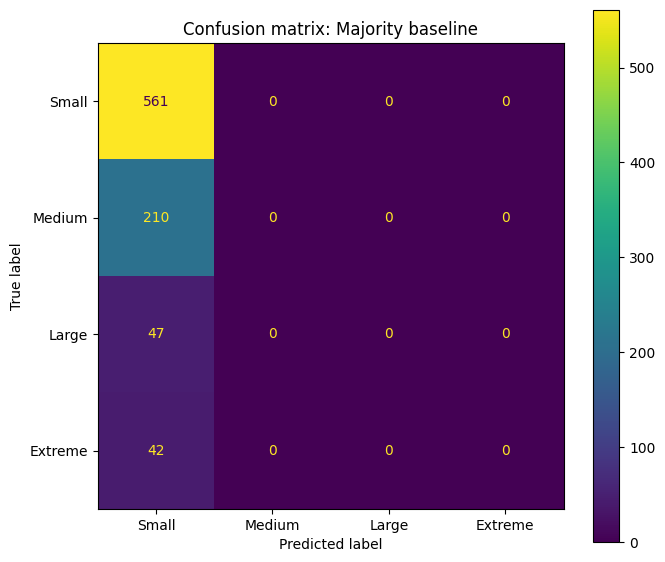

In [14]:
feature_set_name = "curated"
features = curated_features

X_train = train[features].copy()
X_test = test[features].copy()
y_train = train["severity_tier"].astype(str)
y_test = test["severity_tier"].astype(str)

results = []
per_class_results = []

dummy = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent")),
])

dummy_pred = fit_predict_sklearn(dummy, X_train, y_train, X_test)

summary, per_class = evaluate_predictions(y_test, dummy_pred, "Majority baseline")
results.append(summary)
per_class_results.append(per_class)

display(pd.DataFrame(results))
display(per_class)
plot_confusion(y_test, dummy_pred, "Majority baseline")


logistic regression baseline

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
0,Majority baseline,0.652326,0.250000,0.197396,0.515066,0.000000
1,Logistic Regression,0.332558,0.320743,0.251962,0.385288,0.651685


,model,class,precision,recall,f1,support
0,Logistic Regression,Small,0.706093,0.351159,0.469048,561
1,Logistic Regression,Medium,0.250000,0.290476,0.268722,210
2,Logistic Regression,Large,0.054945,0.212766,0.087336,47
3,Logistic Regression,Extreme,0.116129,0.428571,0.182741,42


              precision    recall  f1-score   support

       Small       0.71      0.35      0.47       561
      Medium       0.25      0.29      0.27       210
       Large       0.05      0.21      0.09        47
     Extreme       0.12      0.43      0.18        42

    accuracy                           0.33       860
   macro avg       0.28      0.32      0.25       860
weighted avg       0.53      0.33      0.39       860



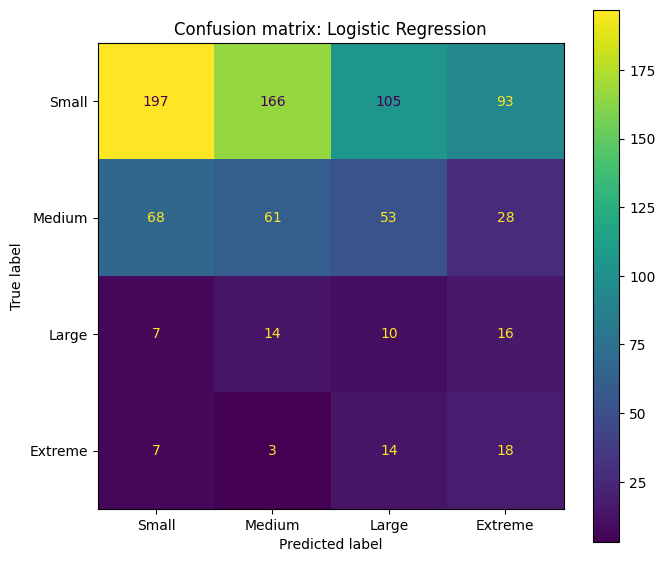

In [15]:
log_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

log_pred = fit_predict_sklearn(log_reg, X_train, y_train, X_test)

summary, per_class = evaluate_predictions(y_test, log_pred, "Logistic Regression")
results.append(summary)
per_class_results.append(per_class)

display(pd.DataFrame(results))
display(per_class)
print(classification_report(y_test, log_pred, labels=tier_order, zero_division=0))
plot_confusion(y_test, log_pred, "Logistic Regression")


random forest baseline

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
0,Majority baseline,0.652326,0.250000,0.197396,0.515066,0.000000
1,Logistic Regression,0.332558,0.320743,0.251962,0.385288,0.651685
2,Random Forest,0.474419,0.365453,0.335819,0.503642,0.438202


,model,class,precision,recall,f1,support
0,Random Forest,Small,0.726392,0.534759,0.616016,561
1,Random Forest,Medium,0.285235,0.404762,0.334646,210
2,Random Forest,Large,0.123457,0.212766,0.156250,47
3,Random Forest,Extreme,0.191176,0.309524,0.236364,42


              precision    recall  f1-score   support

       Small       0.73      0.53      0.62       561
      Medium       0.29      0.40      0.33       210
       Large       0.12      0.21      0.16        47
     Extreme       0.19      0.31      0.24        42

    accuracy                           0.47       860
   macro avg       0.33      0.37      0.34       860
weighted avg       0.56      0.47      0.50       860



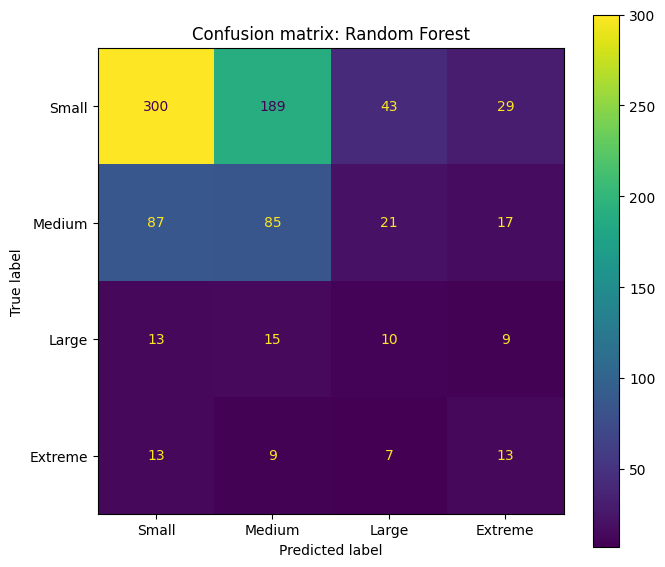

In [16]:
rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pred = fit_predict_sklearn(rf, X_train, y_train, X_test)

summary, per_class = evaluate_predictions(y_test, rf_pred, "Random Forest")
results.append(summary)
per_class_results.append(per_class)

display(pd.DataFrame(results))
display(per_class)
print(classification_report(y_test, rf_pred, labels=tier_order, zero_division=0))
plot_confusion(y_test, rf_pred, "Random Forest")


xgboost baseline

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
0,Majority baseline,0.652326,0.250000,0.197396,0.515066,0.000000
1,Logistic Regression,0.332558,0.320743,0.251962,0.385288,0.651685
2,Random Forest,0.474419,0.365453,0.335819,0.503642,0.438202
3,XGBoost,0.429070,0.323923,0.292647,0.473005,0.528090


,model,class,precision,recall,f1,support
0,XGBoost,Small,0.741667,0.475936,0.579805,561
1,XGBoost,Medium,0.289199,0.395238,0.334004,210
2,XGBoost,Large,0.078571,0.234043,0.117647,47
3,XGBoost,Extreme,0.109589,0.190476,0.139130,42


              precision    recall  f1-score   support

       Small       0.74      0.48      0.58       561
      Medium       0.29      0.40      0.33       210
       Large       0.08      0.23      0.12        47
     Extreme       0.11      0.19      0.14        42

    accuracy                           0.43       860
   macro avg       0.30      0.32      0.29       860
weighted avg       0.56      0.43      0.47       860



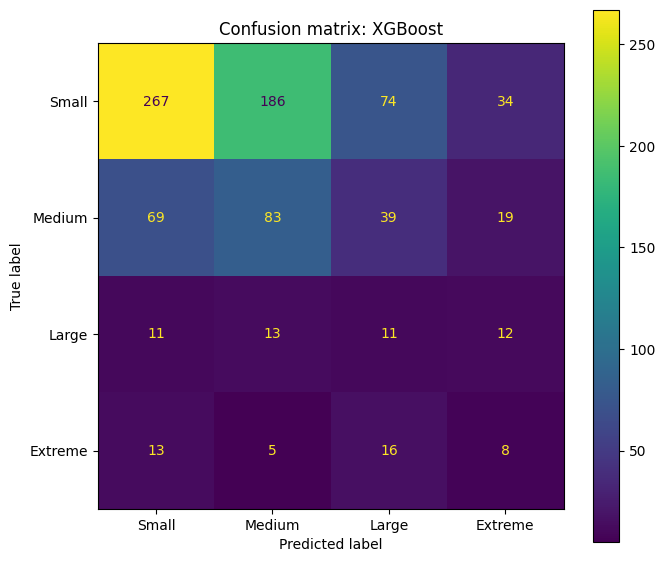

In [17]:
try:
    from xgboost import XGBClassifier

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

    class_counts = y_train.value_counts()
    class_weights = {cls: len(y_train) / (len(class_counts) * count) for cls, count in class_counts.items()}
    sample_weight = y_train.map(class_weights).values

    xgb_imputer = SimpleImputer(strategy="median")
    X_train_imp = xgb_imputer.fit_transform(X_train)
    X_test_imp = xgb_imputer.transform(X_test)

    xgb = XGBClassifier(
        n_estimators=350,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

    xgb.fit(X_train_imp, y_train_encoded, sample_weight=sample_weight)
    xgb_pred_encoded = xgb.predict(X_test_imp)
    xgb_pred = label_encoder.inverse_transform(xgb_pred_encoded)

    summary, per_class = evaluate_predictions(y_test, xgb_pred, "XGBoost")
    results.append(summary)
    per_class_results.append(per_class)

    display(pd.DataFrame(results))
    display(per_class)
    print(classification_report(y_test, xgb_pred, labels=tier_order, zero_division=0))
    plot_confusion(y_test, xgb_pred, "XGBoost")

except ImportError:
    print("xgboost is not installed. Run `pip install xgboost` if you want to include this model.")
except Exception as e:
    print("XGBoost section failed:", e)


comparing models

In [21]:
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
per_class_df = pd.concat(per_class_results, ignore_index=True)

display(results_df.round(4))
display(per_class_df.round(4))

#results_df.to_csv(OUTPUT_DIR / "baseline_model_summary.csv", index=False)
#per_class_df.to_csv(OUTPUT_DIR / "baseline_model_per_class_metrics.csv", index=False)

print("Saved:")
# print(OUTPUT_DIR / "baseline_model_summary.csv")
# print(OUTPUT_DIR / "baseline_model_per_class_metrics.csv")


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
2,Random Forest,0.4744,0.3655,0.3358,0.5036,0.4382
3,XGBoost,0.4291,0.3239,0.2926,0.4730,0.5281
1,Logistic Regression,0.3326,0.3207,0.2520,0.3853,0.6517
0,Majority baseline,0.6523,0.2500,0.1974,0.5151,0.0000


,model,class,precision,recall,f1,support
0,Majority baseline,Small,0.6523,1.0000,0.7896,561
1,Majority baseline,Medium,0.0000,0.0000,0.0000,210
2,Majority baseline,Large,0.0000,0.0000,0.0000,47
3,Majority baseline,Extreme,0.0000,0.0000,0.0000,42
4,Logistic Regression,Small,0.7061,0.3512,0.4690,561
5,Logistic Regression,Medium,0.2500,0.2905,0.2687,210
6,Logistic Regression,Large,0.0549,0.2128,0.0873,47
7,Logistic Regression,Extreme,0.1161,0.4286,0.1827,42
8,Random Forest,Small,0.7264,0.5348,0.6160,561
9,Random Forest,Medium,0.2852,0.4048,0.3346,210


Saved:


random forest feature importance

,feature,importance
11,elevation,0.104306
1,Longitude,0.091590
0,Latitude,0.083642
10,fm1000_pct_30d_mean,0.074518
5,rmin_pct_7d_mean,0.072554
4,vs_m_s_7d_mean,0.067760
3,vpd_kPa_7d_mean,0.065323
9,fm100_pct_7d_mean,0.064146
8,bi_7d_mean,0.062595
7,erc_7d_mean,0.062501


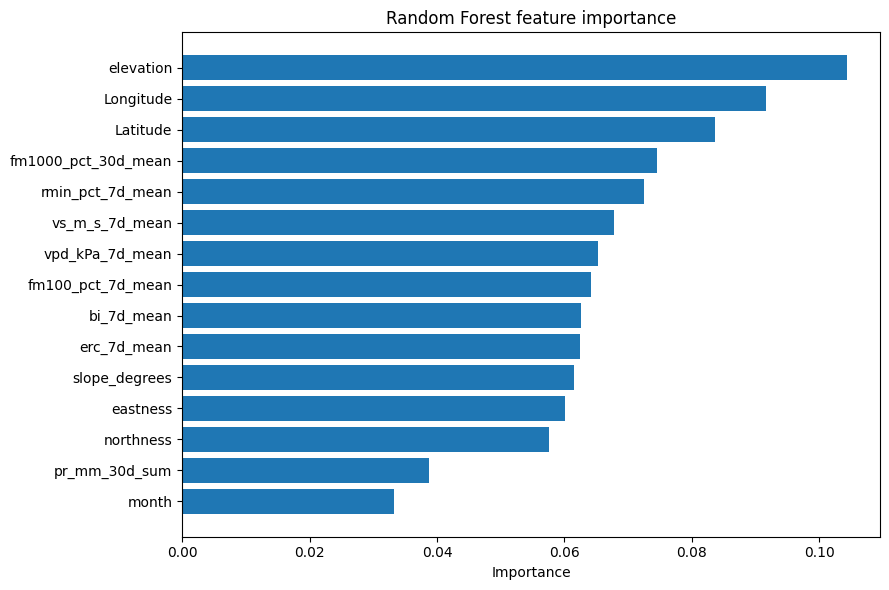

Could not compute Random Forest feature importance: name 'OUTPUT_DIR' is not defined


In [ ]:
try:
    rf_model = rf.named_steps["model"]
    importances = pd.DataFrame({
        "feature": features,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importances.head(25))

    plt.figure(figsize=(9, 6))
    top = importances.head(20).iloc[::-1]
    plt.barh(top["feature"], top["importance"])
    plt.title("Random Forest feature importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    #importances.to_csv(OUTPUT_DIR / "random_forest_feature_importance.csv", index=False)

except Exception as e:
    print("Could not compute Random Forest feature importance:", e)


## 13. Expanded numeric feature experiment

The curated feature set is safer and more interpretable. This section tests whether using more numeric gridMET features improves performance.

If performance improves only slightly, prefer the curated feature set for interpretability.


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
0,Random Forest expanded,0.4756,0.3369,0.3241,0.4981,0.3258


,model,class,precision,recall,f1,support
0,Random Forest expanded,Small,0.6996,0.5686,0.6273,561
1,Random Forest expanded,Medium,0.2439,0.3333,0.2817,210
2,Random Forest expanded,Large,0.1600,0.2553,0.1967,47
3,Random Forest expanded,Extreme,0.1905,0.1905,0.1905,42


              precision    recall  f1-score   support

       Small       0.70      0.57      0.63       561
      Medium       0.24      0.33      0.28       210
       Large       0.16      0.26      0.20        47
     Extreme       0.19      0.19      0.19        42

    accuracy                           0.48       860
   macro avg       0.32      0.34      0.32       860
weighted avg       0.53      0.48      0.50       860



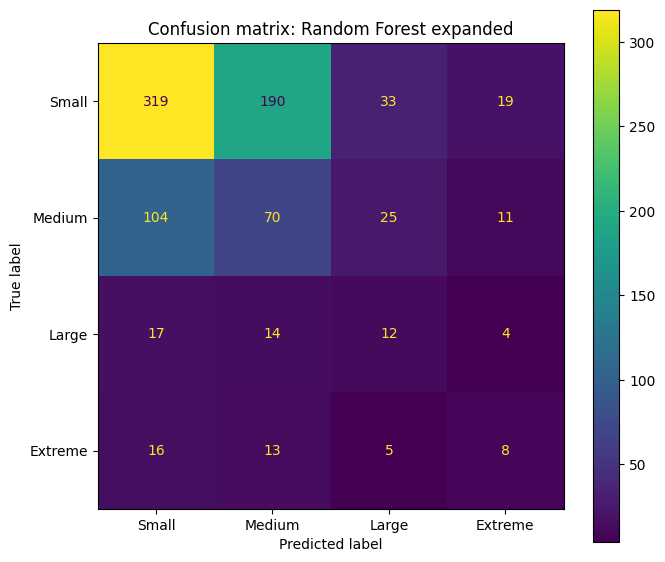

In [23]:
features_expanded = expanded_numeric_features

X_train_exp = train[features_expanded].copy()
X_test_exp = test[features_expanded].copy()

expanded_results = []
expanded_per_class_results = []

rf_expanded = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_exp_pred = fit_predict_sklearn(rf_expanded, X_train_exp, y_train, X_test_exp)

summary, per_class = evaluate_predictions(y_test, rf_exp_pred, "Random Forest expanded")
expanded_results.append(summary)
expanded_per_class_results.append(per_class)

display(pd.DataFrame(expanded_results).round(4))
display(per_class.round(4))
print(classification_report(y_test, rf_exp_pred, labels=tier_order, zero_division=0))
plot_confusion(y_test, rf_exp_pred, "Random Forest expanded")


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
0,Random Forest expanded,0.4756,0.3369,0.3241,0.4981,0.3258
1,XGBoost expanded,0.4698,0.3960,0.3442,0.5056,0.5506


,model,class,precision,recall,f1,support
0,XGBoost expanded,Small,0.7500,0.5241,0.6170,561
1,XGBoost expanded,Medium,0.2952,0.3810,0.3326,210
2,XGBoost expanded,Large,0.1261,0.2979,0.1772,47
3,XGBoost expanded,Extreme,0.1860,0.3810,0.2500,42


              precision    recall  f1-score   support

       Small       0.75      0.52      0.62       561
      Medium       0.30      0.38      0.33       210
       Large       0.13      0.30      0.18        47
     Extreme       0.19      0.38      0.25        42

    accuracy                           0.47       860
   macro avg       0.34      0.40      0.34       860
weighted avg       0.58      0.47      0.51       860



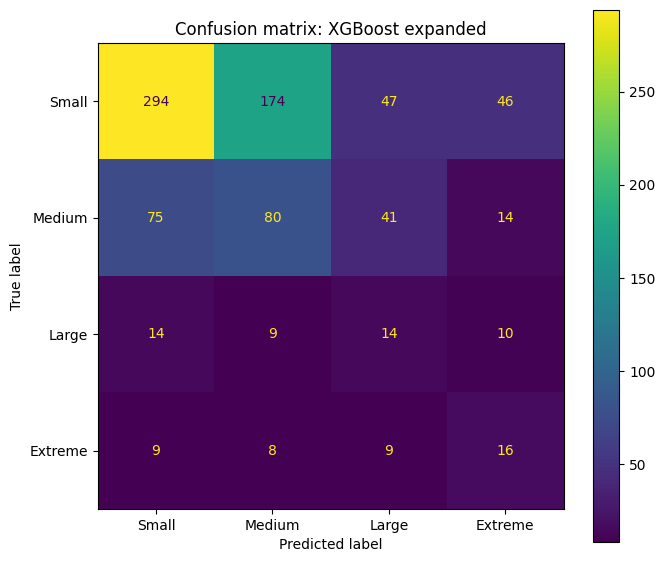

In [24]:
try:
    from xgboost import XGBClassifier

    label_encoder_exp = LabelEncoder()
    y_train_exp_encoded = label_encoder_exp.fit_transform(y_train)
    y_test_exp_encoded = label_encoder_exp.transform(y_test)

    class_counts = y_train.value_counts()
    class_weights = {cls: len(y_train) / (len(class_counts) * count) for cls, count in class_counts.items()}
    sample_weight = y_train.map(class_weights).values

    xgb_exp_imputer = SimpleImputer(strategy="median")
    X_train_exp_imp = xgb_exp_imputer.fit_transform(X_train_exp)
    X_test_exp_imp = xgb_exp_imputer.transform(X_test_exp)

    xgb_exp = XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

    xgb_exp.fit(X_train_exp_imp, y_train_exp_encoded, sample_weight=sample_weight)
    xgb_exp_pred_encoded = xgb_exp.predict(X_test_exp_imp)
    xgb_exp_pred = label_encoder_exp.inverse_transform(xgb_exp_pred_encoded)

    summary, per_class = evaluate_predictions(y_test, xgb_exp_pred, "XGBoost expanded")
    expanded_results.append(summary)
    expanded_per_class_results.append(per_class)

    display(pd.DataFrame(expanded_results).round(4))
    display(per_class.round(4))
    print(classification_report(y_test, xgb_exp_pred, labels=tier_order, zero_division=0))
    plot_confusion(y_test, xgb_exp_pred, "XGBoost expanded")

except ImportError:
    print("xgboost is not installed.")
except Exception as e:
    print("Expanded XGBoost failed:", e)


In [27]:
if expanded_results:
    expanded_results_df = pd.DataFrame(expanded_results)
    expanded_per_class_df = pd.concat(expanded_per_class_results, ignore_index=True)

    combined_summary = pd.concat([results_df, expanded_results_df], ignore_index=True)
    combined_summary = combined_summary.sort_values("macro_f1", ascending=False)

    display(combined_summary.round(4))

    # combined_summary.to_csv(OUTPUT_DIR / "all_model_summary.csv", index=False)
    # expanded_per_class_df.to_csv(OUTPUT_DIR / "expanded_model_per_class_metrics.csv", index=False)

    # print("Saved:", OUTPUT_DIR / "all_model_summary.csv")


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,large_extreme_recall
5,XGBoost expanded,0.4698,0.3960,0.3442,0.5056,0.5506
0,Random Forest,0.4744,0.3655,0.3358,0.5036,0.4382
4,Random Forest expanded,0.4756,0.3369,0.3241,0.4981,0.3258
1,XGBoost,0.4291,0.3239,0.2926,0.4730,0.5281
2,Logistic Regression,0.3326,0.3207,0.2520,0.3853,0.6517
3,Majority baseline,0.6523,0.2500,0.1974,0.5151,0.0000
